# Random Forest para clasificacion de actividades humanas

Se recomienda ver antes el notebook de EDA, porque aqui reutilizamos las caracteristicas que se extraen a partir de la exploracion de las senales. Este notebook se centra en un modelo clasico con scikit-learn: extraccion de features y Random Forest sobre las señales de acelerometro.

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:sklearn.utils.parallel"

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from scipy.stats import randint

In [2]:
SEED = 42
np.random.seed(SEED)

warnings.filterwarnings('ignore')

## Carga de datos y estructura base

Cargamos los csv y los pasamos a la misma estructura con indice jerarquico usada en los otros notebooks, de forma que podamos acceder a los ejes X, Y y Z y a los metadatos de usuario y etiqueta de manera consistente.

In [3]:
data = pd.read_csv('data/train.csv')
predict = pd.read_csv('data/test.csv')

feature_cols = [c for c in predict.columns if c[:1] in {'X', 'Y', 'Z'} and c[1:].isdigit()]
feature_cols = sorted(feature_cols, key=lambda c: (c[0], int(c[1:])))

def to_nested_features(df, cols):
    nested = df[cols].copy()
    nested.columns = pd.MultiIndex.from_tuples(
        [(c[0], int(c[1:])) for c in cols],
        names=['axis', 'sample']
    )

    if 'LABEL' in df.columns and 'USER_ID' in df.columns:
        nested[("META", "LABEL")] = df['LABEL'].to_numpy()
        nested[("META", "USER_ID")] = df['USER_ID'].to_numpy()

    return nested

data = to_nested_features(data, feature_cols)
predict = to_nested_features(predict, feature_cols)

print('Shapes:', (data.shape, predict.shape))
data.head()

Shapes: ((9920, 602), (5120, 600))


axis           X                                                        \
sample         1          2          3         4          5          6   
0       1.582196   1.237512   1.280597  2.233266   2.312256   2.460662   
1      -0.495483  20.712166  15.711853  9.564985  -1.472089  -4.320520   
2       3.822643   7.472944   7.733851  8.054599  18.924117  19.766679   
3       2.393640   2.556407   2.561195  2.565982   2.697632   2.733537   
4       0.406919   0.672613   0.447611 -0.603197  -0.426068  -0.378195   

axis                                             ...         Z            \
sample         7         8         9         10  ...       193       194   
0       2.388853  2.226085  1.737783   1.728208  ...  4.667598  4.959622   
1      -4.806429 -4.772918 -4.507224  -3.552162  ...  0.007181 -1.800017   
2       7.489700 -3.662269  4.085943  11.616335  ...  4.382755  3.477959   
3       2.628217  2.477417  2.283533   2.106403  ...  4.200838  4.155359   
4       0.495483  0.378195  0.603197   0.505058  ...  5.146326  4.904568   

axis                                                                    META  \
sample       195       196        197        198        199        200 LABEL   
0       5.371328  5.230103   5.254040   5.225316   5.122390   4.473713     4   
1       1.180065  3.614396   8.435187  18.048045  12.013679  10.943721     1   
2      -1.077138 -7.190494 -10.105947  -5.996068  -1.632463   0.239364     1   
3       4.162540  3.997379   3.975836   4.085943   4.021315   4.028496     2   
4       4.753769  4.698715   4.696322   4.686747   3.837005   3.817856     4   

axis            
sample USER_ID  
0           13  
1           22  
2            1  
3           19  
4           22  

[5 rows x 602 columns]

## Extraccion de caracteristicas

Usamos las mismas familias de caracteristicas que se exploraron en EDA: intensidad, periodicidad, dinamica, frecuencia y complejidad. La frecuencia se resume con una PSD calculada sobre la magnitud de la senal, y a partir de ella obtenemos frecuencia dominante, centroide espectral y potencia por bandas.

In [4]:
def zcr_rows(arr):
    return (np.diff(np.signbit(arr), axis=1) != 0).sum(axis=1) / (arr.shape[1] - 1)

def compute_feature_table(df):
    X = df['X'].to_numpy()
    Y = df['Y'].to_numpy()
    Z = df['Z'].to_numpy()

    _, n_steps = X.shape
    fs = 50.0
    timestep = 1.0 / fs

    mag = np.sqrt(X**2 + Y**2 + Z**2)
    energia = (X**2 + Y**2 + Z**2).sum(axis=1)

    rms_mag = np.sqrt(np.mean(mag**2, axis=1))
    sma = (np.abs(X) + np.abs(Y) + np.abs(Z)).mean(axis=1)

    zcr_mean = (zcr_rows(X) + zcr_rows(Y) + zcr_rows(Z)) / 3.0

    dX = np.diff(X, axis=1) / timestep
    dY = np.diff(Y, axis=1) / timestep
    dZ = np.diff(Z, axis=1) / timestep
    jerk_mag = np.sqrt(dX**2 + dY**2 + dZ**2)
    jerk_rms = np.sqrt(np.mean(jerk_mag**2, axis=1))

    freqs = np.fft.rfftfreq(n_steps, d=timestep)
    psd = np.abs(np.fft.rfft(mag, axis=1))**2
    psd_sum = psd.sum(axis=1)

    dominant_idx = np.argmax(psd[:, 1:], axis=1) + 1
    dominant_freq = freqs[dominant_idx]
    spectral_centroid = np.divide((psd * freqs).sum(axis=1), psd_sum, out=np.zeros_like(psd_sum), where=psd_sum > 0)

    low_band = (freqs >= 0.0) & (freqs < 3.0)
    mid_band = (freqs >= 3.0) & (freqs < 8.0)
    high_band = (freqs >= 8.0) & (freqs <= 20.0)

    bandpower_low = psd[:, low_band].sum(axis=1)
    bandpower_mid = psd[:, mid_band].sum(axis=1)
    bandpower_high = psd[:, high_band].sum(axis=1)

    p_spec = np.divide(psd, psd_sum[:, None], out=np.zeros_like(psd), where=psd_sum[:, None] > 0)
    spectral_entropy = -(p_spec * np.log(p_spec + 1e-12)).sum(axis=1) / np.log(p_spec.shape[1])

    mag_centered = mag - mag.mean(axis=1, keepdims=True)
    ac_num = (mag_centered[:, :-1] * mag_centered[:, 1:]).sum(axis=1)
    ac_den = (mag_centered**2).sum(axis=1)
    autocorr_lag1 = np.divide(ac_num, ac_den, out=np.zeros_like(ac_num), where=ac_den > 0)

    feature_data = {
        'energia': energia,
        'rms_mag': rms_mag,
        'sma': sma,
        'zcr_mean': zcr_mean,
        'jerk_rms': jerk_rms,
        'dominant_freq': dominant_freq,
        'spectral_centroid': spectral_centroid,
        'bandpower_low': bandpower_low,
        'bandpower_mid': bandpower_mid,
        'bandpower_high': bandpower_high,
        'spectral_entropy': spectral_entropy,
        'autocorr_lag1': autocorr_lag1,
    }

    if 'META' in df.columns:
        feature_data['USER_ID'] = df['META']['USER_ID'].astype(int)
        feature_data['LABEL_ID'] = df['META']['LABEL'].astype(int)
        feature_data['LABEL'] = df['META']['LABEL'].map(labels)

    return pd.DataFrame(feature_data)

labels = {1: 'Skip', 2: 'Twist', 3: 'Jump', 4: 'Step'}

train_features = compute_feature_table(data).dropna().reset_index(drop=True)
predict_features = compute_feature_table(predict).dropna().reset_index(drop=True)

feature_cols = [
    'energia',
    'rms_mag',
    'sma',
    'zcr_mean',
    'jerk_rms',
    'dominant_freq',
    'spectral_centroid',
    'bandpower_low',
    'bandpower_mid',
    'bandpower_high',
    'spectral_entropy',
    'autocorr_lag1',
]

train_features[['LABEL', 'USER_ID'] + feature_cols].head()

,LABEL,USER_ID,energia,rms_mag,sma,zcr_mean,jerk_rms,dominant_freq,spectral_centroid,bandpower_low,bandpower_mid,bandpower_high,spectral_entropy,autocorr_lag1
0,Step,13,19835.441994,9.958776,14.640699,0.020101,45.757853,2.75,0.047634,3.899643e+06,1.226262e+04,5.174777e+03,0.023675,0.845778
1,Skip,22,92748.565173,21.534689,22.609749,0.154104,877.150055,3.25,2.108408,9.923071e+06,2.811422e+06,1.335015e+06,0.321251,0.552772
2,Skip,1,166418.487708,28.846013,31.082145,0.189280,1027.064801,3.00,1.758388,2.002114e+07,4.167535e+06,2.385608e+06,0.241848,0.573407
3,Twist,19,18993.236461,9.745059,14.559207,0.000000,19.938103,6.75,0.003000,3.795416e+06,1.074543e+03,2.940214e+02,0.001267,0.647573
4,Step,22,21554.687695,10.381399,15.030826,0.040201,121.211357,2.75,0.146639,4.088322e+06,5.780107e+04,1.313826e+04,0.060423,0.821574


## Hold-out por sujeto

Hacemos una particion 80/20 por usuarios para comprobar rapidamente si las features tienen capacidad de generalizacion entre sujetos, que es la parte mas exigente del problema.

In [5]:
groups = train_features['USER_ID'].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(train_features, groups=groups))

train_df = train_features.iloc[train_idx].reset_index(drop=True)
val_df = train_features.iloc[val_idx].reset_index(drop=True)

users_train = set(train_df['USER_ID'].unique())
users_val = set(val_df['USER_ID'].unique())
assert users_train.isdisjoint(users_val), 'Hay usuarios mezclados entre train y val'

X_train = train_df[feature_cols].to_numpy()
y_train = train_df['LABEL_ID'].to_numpy() - 1
X_val = val_df[feature_cols].to_numpy()
y_val = val_df['LABEL_ID'].to_numpy() - 1

### Búsqueda aleatoria de hiperparámetros

Optimizamos el Random Forest con una búsqueda aleatoria sobre el conjunto de entrenamiento usando validación cruzada por grupos de sujeto. Esto evita mezclar usuarios entre folds y mantiene el criterio de generalización del problema.

In [6]:
param_distributions = {
    'n_estimators': randint(200, 700),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 6),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}

cv = GroupKFold(n_splits=5)
rf_base = RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced_subsample')

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=-3,
    refit=True,
)

random_search.fit(X_train, y_train, groups=train_df['USER_ID'].to_numpy())

print('Mejores hiperparametros:')
print(random_search.best_params_)
print(f'Best CV accuracy: {random_search.best_score_:.4f}')

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/diego/Desktop/RF APSE/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/diego/Desktop/RF APSE/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/diego/Desktop/RF APSE/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/diego/Desktop/RF APSE/.venv/li

Mejores hiperparametros:
{'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 544}
Best CV accuracy: 0.8845


## Random Forest optimizado

Entrenamos un Random Forest con scikit-learn usando los mejores hiperparámetros encontrados con la búsqueda aleatoria.

In [7]:
best_rf = random_search.best_estimator_

val_preds = best_rf.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)

print(f'Validation accuracy: {val_acc:.4f}')
print()
print(classification_report(y_val, val_preds, target_names=[labels[i + 1] for i in range(4)]))

Validation accuracy: 0.8754

              precision    recall  f1-score   support

        Skip       0.91      0.80      0.85       560
       Twist       0.91      0.90      0.91       560
        Jump       0.96      0.91      0.93       560
        Step       0.75      0.89      0.82       560

    accuracy                           0.88      2240
   macro avg       0.88      0.88      0.88      2240
weighted avg       0.88      0.88      0.88      2240



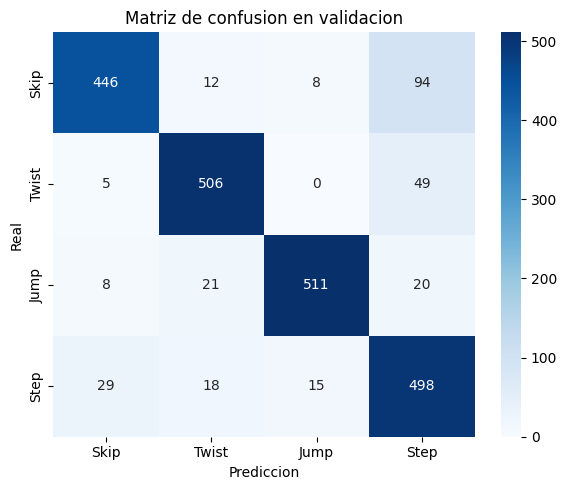

In [8]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[labels[i + 1] for i in range(4)], yticklabels=[labels[i + 1] for i in range(4)])
plt.title('Matriz de confusion en validacion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

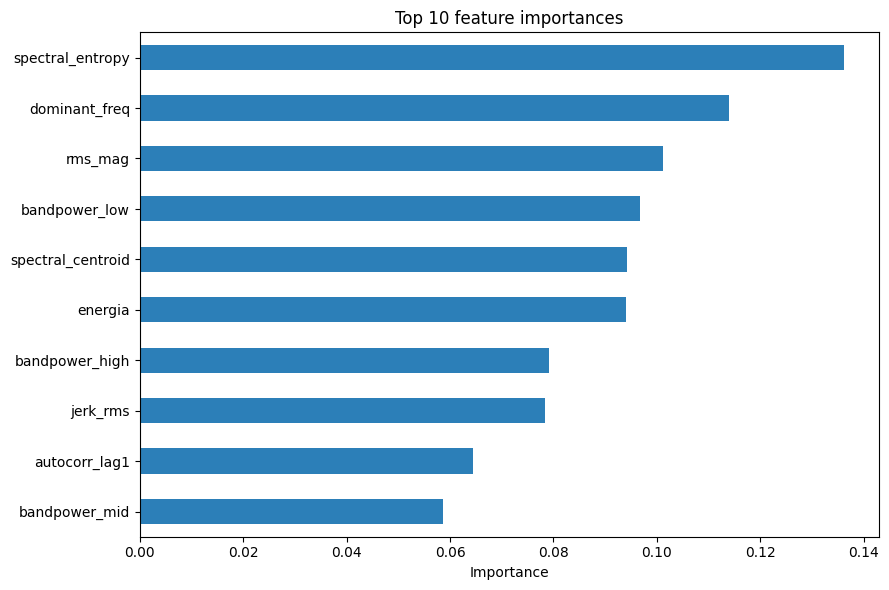

In [9]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.tail(10).plot(kind='barh', color='#2c7fb8')
plt.title('Top 10 feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Prediccion final sobre test

Reentrenamos el modelo con todas las muestras etiquetadas y generamos las predicciones para el conjunto de test.

In [10]:
X_full = train_features[feature_cols].to_numpy()
y_full = train_features['LABEL_ID'].to_numpy() - 1
X_test = predict_features[feature_cols].to_numpy()

rf_final = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced_subsample',
    **random_search.best_params_,
)
rf_final.fit(X_full, y_full)

test_preds = rf_final.predict(X_test) + 1
submission_df = pd.DataFrame({'y_test_pred': test_preds})

assert len(submission_df) == len(predict), 'El numero de predicciones no coincide con el test oficial'
assert submission_df['y_test_pred'].between(1, 4).all(), 'Hay etiquetas fuera de [1, 4]'

submission_path = 'artifacts/rf_predictions.csv'
submission_df.to_csv(submission_path, index=False)

print(f'CSV generado: {submission_path}')
submission_df.head()

CSV generado: artifacts/rf_predictions.csv


,y_test_pred
0,3
1,2
2,1
3,3
4,2
